In [2]:
!pip install -U langchain
!pip install -U langgraph
!pip install -U langchain-google-genai
!pip install -U langchain-huggingface
!pip install -U faiss-cpu
!pip install -U sentence-transformers

In [3]:
from google.colab import userdata
import os

gemini_api_key = userdata.get("GOOGLE_API_KEY")

os.environ["GOOGLE_API_KEY"] = gemini_api_key

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_huggingface import HuggingFaceEmbeddings

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [5]:
!pip install langchain_community

In [6]:
from langchain_community.vectorstores import FAISS

/tmp/ipykernel_2083/1059762981.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [7]:
#from langchain.vectorstores import FAISS
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

#from langchain.schema import Document

docs = [
    Document(page_content="High engine temperature may indicate coolant leak or radiator failure."),
    Document(page_content="Low battery voltage often suggests battery degradation."),
    Document(page_content="Brake pressure loss is usually caused by hydraulic fluid leakage."),
    Document(page_content="Brake system faults are safety critical and require immobilization.")
]

vectorstore = FAISS.from_documents(docs, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})


In [8]:
from typing import TypedDict, List, Dict

class VehicleState(TypedDict):
    vehicle_id: str
    telemetry: Dict[str, float]
    anomaly: str
    retrieved_docs: List[str]
    diagnosis: str
    decision: str


In [9]:
def telemetry_node(state: VehicleState):
    return state


In [10]:
def anomaly_node(state: VehicleState):
    t = state["telemetry"]

    if t["engine_temp"] > 110:
        state["anomaly"] = "High engine temperature"
    elif t["battery_voltage"] < 11.5:
        state["anomaly"] = "Low battery voltage"
    elif t["brake_pressure"] < 20:
        state["anomaly"] = "Brake pressure loss"
    else:
        state["anomaly"] = "Normal"

    return state


In [11]:
def retrieval_node(state: VehicleState):
    docs = retriever.invoke(state["anomaly"])
    state["retrieved_docs"] = [d.page_content for d in docs]
    return state


In [12]:
def diagnosis_node(state: VehicleState):
    context = "\n".join(state["retrieved_docs"])

    prompt = f"""
    You are an automotive diagnostics expert.

    Telemetry:
    {state["telemetry"]}

    Detected anomaly:
    {state["anomaly"]}

    Relevant knowledge:
    {context}

    Identify the most likely root cause.
    """

    response = llm.invoke(prompt)
    state["diagnosis"] = response.content
    return state


In [13]:
def decision_node(state: VehicleState):
    prompt = f"""
    You are a fleet safety AI.

    Diagnosis:
    {state["diagnosis"]}

    Decide the safest action.
    Constraints:
    - Human safety first
    - Vehicle protection second
    - Cost last

    Respond with ONE action.
    """

    response = llm.invoke(prompt)
    state["decision"] = response.content
    return state


In [14]:
def report_node(state: VehicleState):
    print("\n===== VEHICLE INCIDENT REPORT =====")
    print("Vehicle ID:", state["vehicle_id"])
    print("Telemetry:", state["telemetry"])
    print("Anomaly:", state["anomaly"])
    print("Diagnosis:", state["diagnosis"])
    print("Decision:", state["decision"])
    print("=================================\n")

    return state


In [15]:
from langgraph.graph import StateGraph, END

graph = StateGraph(VehicleState)

graph.add_node("telemetry", telemetry_node)
graph.add_node("anomaly", anomaly_node)
graph.add_node("retrieve", retrieval_node)
graph.add_node("diagnose", diagnosis_node)
graph.add_node("decide", decision_node)
graph.add_node("report", report_node)

graph.set_entry_point("telemetry")

graph.add_edge("telemetry", "anomaly")
graph.add_edge("anomaly", "retrieve")
graph.add_edge("retrieve", "diagnose")
graph.add_edge("diagnose", "decide")
graph.add_edge("decide", "report")
graph.add_edge("report", END)

app = graph.compile()


In [16]:
initial_state = {
    "vehicle_id": "CAR-9001",
    "telemetry": {
        "engine_temp": 128,
        "battery_voltage": 12.1,
        "brake_pressure": 30
    },
    "anomaly": "",
    "retrieved_docs": [],
    "diagnosis": "",
    "decision": ""
}

app.invoke(initial_state)



===== VEHICLE INCIDENT REPORT =====
Vehicle ID: CAR-9001
Telemetry: {'engine_temp': 128, 'battery_voltage': 12.1, 'brake_pressure': 30}
Anomaly: High engine temperature
Diagnosis: Based on the telemetry and detected anomaly:

*   **Detected Anomaly:** High engine temperature (128 degrees)
*   **Relevant Knowledge for Anomaly:** High engine temperature may indicate coolant leak or radiator failure.
*   **Other Telemetry:** Low battery voltage (12.1V) is also present, which often suggests battery degradation.

The question asks for the most likely root cause of the *detected anomaly* (high engine temperature).

**Most likely root cause:**
A **coolant leak or radiator failure** is the most likely root cause for the high engine temperature, as directly indicated by the relevant knowledge. While the low battery voltage is another issue, it is not presented as a direct cause for high engine temperature in the provided knowledge.
Decision: Stop the vehicle immediately and shut down the engin

{'vehicle_id': 'CAR-9001',
 'telemetry': {'engine_temp': 128,
  'battery_voltage': 12.1,
  'brake_pressure': 30},
 'anomaly': 'High engine temperature',
 'retrieved_docs': ['High engine temperature may indicate coolant leak or radiator failure.',
  'Low battery voltage often suggests battery degradation.'],
 'diagnosis': 'Based on the telemetry and detected anomaly:\n\n*   **Detected Anomaly:** High engine temperature (128 degrees)\n*   **Relevant Knowledge for Anomaly:** High engine temperature may indicate coolant leak or radiator failure.\n*   **Other Telemetry:** Low battery voltage (12.1V) is also present, which often suggests battery degradation.\n\nThe question asks for the most likely root cause of the *detected anomaly* (high engine temperature).\n\n**Most likely root cause:**\nA **coolant leak or radiator failure** is the most likely root cause for the high engine temperature, as directly indicated by the relevant knowledge. While the low battery voltage is another issue, it 

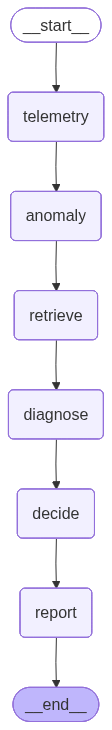

In [17]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))